# Zero-Shot Error-Type Classification with LLaVA-Critic-7B on MMErroR

This notebook evaluates **LLaVA-Critic-7B** as a zero-shot multimodal judge on a
balanced 300-sample subset of MMErroR.

### Evaluation design

The experiment retains three MMErroR error categories:

- **A — Visual Perception Error (VPE)**
- **B — Reasoning Error (RE)**
- **D — Knowledge Deployment Error (KDE)**

**Question Comprehension Error (QCE) is excluded from both sampling and the
classification prompt.**

The evaluation cohort contains exactly **300 samples**, selected with a fixed
random seed:

- 100 VPE samples
- 100 RE samples
- 100 KDE samples

For each sample, the judge receives the **image, question, and erroneous
reasoning** and must return exactly one label: `A`, `B`, or `D`.

The primary metrics are **Accuracy**, **Macro-F1**, class-wise
Precision/Recall/F1, and the Confusion Matrix. Bootstrap 95% confidence
intervals are additionally reported for Accuracy and Macro-F1.

## 1. Environment and Reproducibility

Recommended Kaggle configuration:

- **Accelerator:** GPU T4 ×2
- **Internet:** ON
- **Random seed:** 42

The notebook deliberately stops before model loading if Kaggle assigns a
different accelerator, preventing GPU time from being wasted on an unintended
P100 session.

In [1]:
# 1.1 — Verify the Kaggle GPU allocation

import subprocess

gpu_lines = subprocess.check_output(
    ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
    text=True,
).strip().splitlines()

gpu_names = [line.split(",")[0].strip() for line in gpu_lines]

print("Detected GPUs:")
for idx, line in enumerate(gpu_lines):
    print(f"  GPU {idx}: {line}")

if len(gpu_names) != 2 or not all("T4" in name for name in gpu_names):
    raise RuntimeError(
        "This experiment is configured for Kaggle T4 x2. "
        f"Detected GPUs: {gpu_names}. Stop the session, request T4 x2, "
        "and restart the notebook."
    )

print("\nGPU allocation verified: T4 x2.")

Detected GPUs:
  GPU 0: Tesla T4, 15360 MiB
  GPU 1: Tesla T4, 15360 MiB

GPU allocation verified: T4 x2.


In [2]:
# 1.2 — Install the controlled LLaVA-NeXT environment

TRANSFORMERS_COMMIT = "1c39974a4c4036fd641bc1191cc32799f85715a4"

!pip uninstall -y llava llava-next transformers tokenizers > /dev/null 2>&1 || true
!pip install -q --no-cache-dir "tokenizers==0.15.2"
!pip install -q --no-cache-dir --no-deps \
    "git+https://github.com/huggingface/transformers.git@{TRANSFORMERS_COMMIT}"
!pip install -q --no-cache-dir --no-deps \
    "git+https://github.com/LLaVA-VL/LLaVA-NeXT.git"
!pip install -q \
    "accelerate>=0.29.1" sentencepiece einops einops-exts timm shortuuid ftfy \
    safetensors huggingface_hub pyarrow pandas scikit-learn tqdm pillow \
    bitsandbytes

print("Environment installation completed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 331.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, which is not installed.
peft 0.19.1 requires transformers, which is not installed.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 38.5 MB/s eta 0:00:00
Environment installation completed.


In [3]:
# 1.3 — Verify compatibility and patch the unnecessary legacy top-level import

import sys
import transformers
import tokenizers
from pathlib import Path
from importlib.metadata import distribution

from transformers.modeling_utils import (
    PreTrainedModel,
    apply_chunking_to_forward,
    find_pruneable_heads_and_indices,
    prune_linear_layer,
)

llava_init = Path(distribution("llava").locate_file("llava/__init__.py"))
llava_init.write_text(
    "# Compatibility shim for Qwen-based LLaVA-OneVision models.\n",
    encoding="utf-8",
)

for module_name in list(sys.modules):
    if module_name == "llava" or module_name.startswith("llava."):
        del sys.modules[module_name]

from llava.model.language_model.llava_qwen import LlavaQwenForCausalLM
from llava.model.builder import load_pretrained_model
from llava.mm_utils import process_images, tokenizer_image_token
from llava.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN
from llava.conversation import conv_templates

print("Transformers :", transformers.__version__)
print("Tokenizers   :", tokenizers.__version__)
print("LLaVA-Qwen compatibility check passed.")

Please install pyav to use video processing functions.
OpenCLIP not installed
Transformers : 4.40.0.dev0
Tokenizers   : 0.15.2
LLaVA-Qwen compatibility check passed.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [4]:
# 1.4 — Imports and experiment configuration

import io
import gc
import re
import json
import time
import copy
import random
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DATA_PATH = Path(
    "/kaggle/input/notebooks/vernvern/glimmer/"
    "mmerror_muse_glimmer_30b_eval/mmerror_complete.parquet"
)

OUTPUT_DIR = Path(
    "/kaggle/working/llava_critic_mmerror_300_balanced"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ID = "lmms-lab/llava-critic-7b"
MODEL_NAME = "llava_qwen"
CONVERSATION_TEMPLATE = "qwen_1_5"

CLASS_QUOTAS = {"A": 100, "B": 100, "D": 100}
TARGET_LABELS = ["A", "B", "D"]
N_SAMPLES = sum(CLASS_QUOTAS.values())

MAX_NEW_TOKENS = 8
ALLOW_4BIT_FALLBACK = True

assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH}"

print("Python :", platform.python_version())
print("PyTorch:", torch.__version__)
print("CUDA   :", torch.version.cuda)

Python : 3.12.13
PyTorch: 2.10.0+cu128
CUDA   : 12.8


## 2. Dataset and Evaluation Cohort

The dataset is read directly from the local Parquet file already available in
the Kaggle input directory. No MMErroR download is performed.

The 300-sample cohort is created by independent random sampling within each of
the three retained error classes. The selected question identifiers are saved
so that the same cohort can later be reused for the post-fine-tuning
evaluation.

In [5]:
# 2.1 — Load and validate the MMErroR Parquet file

df = pd.read_parquet(DATA_PATH)

REQUIRED_COLUMNS = {
    "question_id",
    "question",
    "error_reason",
    "label",
    "domain",
    "subdomain",
    "image_bytes",
}

missing_columns = REQUIRED_COLUMNS.difference(df.columns)
if missing_columns:
    raise KeyError(f"Missing required columns: {sorted(missing_columns)}")

LABEL_MAP = {
    "A_Visual_Perception_Error": "A",
    "B_Reasoning_Error": "B",
    "C_Question_Comprehension_Error": "C",
    "D_Knowledge_Deployment_Error": "D",
}

df = df.copy()
df["label_letter"] = df["label"].map(LABEL_MAP)

if df["label_letter"].isna().any():
    unknown = df.loc[df["label_letter"].isna(), "label"].value_counts()
    raise ValueError(f"Unknown labels found:\n{unknown}")

print(f"MMErroR samples: {len(df):,}")
print("\nFull class distribution:")
print(df["label_letter"].value_counts().sort_index())

MMErroR samples: 1,997

Full class distribution:
label_letter
A    636
B    234
C    247
D    880
Name: count, dtype: int64


In [6]:
# 2.2 — Construct the balanced 300-sample evaluation cohort

evaluation_pool = df[df["label_letter"].isin(TARGET_LABELS)].copy()

sampled_groups = []

for label, n_samples in CLASS_QUOTAS.items():
    class_data = evaluation_pool[
        evaluation_pool["label_letter"] == label
    ]

    if len(class_data) < n_samples:
        raise ValueError(
            f"Class {label}: requested {n_samples}, available {len(class_data)}"
        )

    sampled_groups.append(
        class_data.sample(
            n=n_samples,
            replace=False,
            random_state=SEED,
        )
    )

evaluation_df = (
    pd.concat(sampled_groups, ignore_index=True)
    .sample(frac=1.0, random_state=SEED)
    .reset_index(drop=True)
)

assert len(evaluation_df) == 300
assert "C" not in set(evaluation_df["label_letter"])
assert evaluation_df["label_letter"].value_counts().to_dict() == {
    "A": 100,
    "B": 100,
    "D": 100,
}

print("Evaluation cohort:")
print(evaluation_df["label_letter"].value_counts().sort_index())

print("\nDomain distribution:")
print(evaluation_df["domain"].value_counts())

print("\nNumber of subdomains:", evaluation_df["subdomain"].nunique())

Evaluation cohort:
label_letter
A    100
B    100
D    100
Name: count, dtype: int64

Domain distribution:
domain
Earth & Environment      65
Mathematics & Logic      60
Physics & Engineering    56
Biology & Healthcare     53
Data & Analytics         45
Chemistry & Materials    21
Name: count, dtype: int64

Number of subdomains: 24


In [7]:
# 2.3 — Save the fixed evaluation cohort

evaluation_ids = evaluation_df["question_id"].astype(str).tolist()

with open(
    OUTPUT_DIR / "evaluation_300_ids.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(evaluation_ids, f, ensure_ascii=False, indent=2)

evaluation_df[
    [
        "question_id",
        "question",
        "error_reason",
        "label",
        "label_letter",
        "domain",
        "subdomain",
    ]
].to_csv(
    OUTPUT_DIR / "evaluation_300_metadata.csv",
    index=False,
)

print("Fixed evaluation cohort saved.")

Fixed evaluation cohort saved.


## 3. Error-Type Classification Prompt

The judge is explicitly informed that the supplied reasoning is already
incorrect. Therefore, the task is **error-type diagnosis**, not correctness
detection.

The operational class definitions are restricted to VPE, RE, and KDE because
QCE is outside the scope of this experiment.

In [8]:
# 3.1 — Define the three-class taxonomy and prompt

CATEGORY_DEFINITIONS = """A. Visual Perception Error
The response incorrectly interprets visual evidence, such as text, numbers,
objects, positions, colors, counts, chart values, or image-grounded relations.
The subsequent reasoning may be internally consistent given the incorrect
visual input.

B. Reasoning Error
The relevant visual information is correctly perceived, but the response makes
an invalid arithmetic, logical, compositional, unit-related, proportional, or
multi-step reasoning transition.

D. Knowledge Deployment Error
The image and task are correctly understood, but the response retrieves,
selects, or applies an incorrect domain fact, law, formula, rule, concept, or
other external knowledge."""


def build_prompt(question: str, erroneous_reasoning: str) -> str:
    return f"""You are evaluating an erroneous multimodal reasoning chain.

The reasoning chain is known to be incorrect.
Classify its primary error into exactly ONE of the categories below.

{CATEGORY_DEFINITIONS}

Question:
{question}

Erroneous reasoning:
{erroneous_reasoning}

STRICT OUTPUT FORMAT:
Return exactly one uppercase letter: A, B, or D.
Do not output an explanation, punctuation, markdown, or any additional text.

Answer:"""

## 4. Model Loading and Inference

In [9]:
# 4.1 — Decode images stored in the Parquet file

def decode_image(image_value) -> Image.Image:
    if isinstance(image_value, memoryview):
        image_value = image_value.tobytes()

    if isinstance(image_value, bytearray):
        image_value = bytes(image_value)

    if not isinstance(image_value, bytes):
        raise TypeError(
            f"Expected bytes-like image data, received {type(image_value)}"
        )

    return Image.open(io.BytesIO(image_value)).convert("RGB")


test_image = decode_image(evaluation_df.loc[0, "image_bytes"])
print("Image decoding check:", test_image.size, test_image.mode)

Image decoding check: (758, 165) RGB


In [10]:
# 4.2 — Load LLaVA-Critic-7B

def clear_cuda_memory():
    gc.collect()
    torch.cuda.empty_cache()
    try:
        torch.cuda.ipc_collect()
    except Exception:
        pass


LOAD_MODE = "standard"

try:
    tokenizer, model, image_processor, model_max_length = load_pretrained_model(
        MODEL_ID,
        None,
        MODEL_NAME,
        device_map="auto",
        attn_implementation="sdpa",
    )

except Exception as first_error:
    print("Standard loading failed:")
    print(repr(first_error))

    if not ALLOW_4BIT_FALLBACK:
        raise

    print("\nRetrying with 4-bit NF4 quantization...")
    clear_cuda_memory()

    tokenizer, model, image_processor, model_max_length = load_pretrained_model(
        MODEL_ID,
        None,
        MODEL_NAME,
        device_map="auto",
        load_4bit=True,
        attn_implementation="sdpa",
    )

    LOAD_MODE = "4bit_nf4"

model.eval()

print("\nModel loaded successfully.")
print("Load mode       :", LOAD_MODE)
print("Model max length:", model_max_length)

if hasattr(model, "hf_device_map"):
    print("\nDevice map:")
    print(model.hf_device_map)

Loaded LLaVA model: lmms-lab/llava-critic-7b


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


generation_config.json:   0%|          | 0.00/248 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/accelerate/utils/modeling.py:1598: UserWarning: The following device_map keys do not match any submodules in the model: ['model.image_newline']
  warnings.warn(


Model Class: LlavaQwenForCausalLM

Model loaded successfully.
Load mode       : standard
Model max length: 32768

Device map:
{'model.image_newline': 0, 'model.embed_tokens': 0, 'model.layers.0': 0, 'model.layers.1': 0, 'model.layers.2': 0, 'model.layers.3': 0, 'model.layers.4': 0, 'model.layers.5': 0, 'model.layers.6': 0, 'model.layers.7': 0, 'model.layers.8': 0, 'model.layers.9': 0, 'model.layers.10': 0, 'model.layers.11': 0, 'model.layers.12': 0, 'model.layers.13': 1, 'model.layers.14': 1, 'model.layers.15': 1, 'model.layers.16': 1, 'model.layers.17': 1, 'model.layers.18': 1, 'model.layers.19': 1, 'model.layers.20': 1, 'model.layers.21': 1, 'model.layers.22': 1, 'model.layers.23': 1, 'model.layers.24': 1, 'model.layers.25': 1, 'model.layers.26': 1, 'model.layers.27': 1, 'model.norm': 1, 'model.vision_tower': 1, 'model.vision_resampler': 1, 'model.mm_projector': 1, 'lm_head': 1}


In [11]:
# 4.3 — Resolve the text and vision devices

def module_device(module, fallback=torch.device("cuda:0")):
    try:
        return next(module.parameters()).device
    except Exception:
        return fallback


text_device = model.get_input_embeddings().weight.device

vision_tower = model.get_vision_tower()
if isinstance(vision_tower, (list, tuple)):
    vision_tower = vision_tower[0]

vision_device = module_device(vision_tower)

print("Text device  :", text_device)
print("Vision device:", vision_device)

Text device  : cuda:0
Vision device: cuda:1


In [12]:
# 4.4 — Parse the constrained model output

def parse_prediction(raw_text: str):
    raw = str(raw_text).strip()

    exact = re.fullmatch(r"([ABD])", raw, flags=re.IGNORECASE)
    if exact:
        return exact.group(1).upper(), True

    cleaned = re.sub(r"</?think>", "", raw, flags=re.IGNORECASE).strip()

    fallback = re.fullmatch(
        r"[*_`~$]*\(?\s*([ABD])\s*\)?[*_`~$]*[.!?:]*",
        cleaned,
        flags=re.IGNORECASE,
    )
    if fallback:
        return fallback.group(1).upper(), False

    explicit = re.search(
        r"(?:final\s*answer|answer|output|classification)"
        r"\s*[:\-]?\s*([ABD])\b",
        cleaned,
        flags=re.IGNORECASE,
    )
    if explicit:
        return explicit.group(1).upper(), False

    return None, False

In [13]:
# 4.5 — Define deterministic single-sample inference

def move_image_tensor(image_tensor, device):
    if isinstance(image_tensor, list):
        return [
            tensor.to(device=device, dtype=torch.float16)
            for tensor in image_tensor
        ]

    return image_tensor.to(device=device, dtype=torch.float16)


def infer_sample(row):
    image = decode_image(row["image_bytes"])

    user_prompt = DEFAULT_IMAGE_TOKEN + "\n" + build_prompt(
        question=str(row["question"]),
        erroneous_reasoning=str(row["error_reason"]),
    )

    conversation = copy.deepcopy(
        conv_templates[CONVERSATION_TEMPLATE]
    )
    conversation.append_message(conversation.roles[0], user_prompt)
    conversation.append_message(conversation.roles[1], None)

    formatted_prompt = conversation.get_prompt()

    input_ids = tokenizer_image_token(
        formatted_prompt,
        tokenizer,
        IMAGE_TOKEN_INDEX,
        return_tensors="pt",
    ).unsqueeze(0).to(text_device)

    image_tensor = process_images(
        [image],
        image_processor,
        model.config,
    )
    image_tensor = move_image_tensor(image_tensor, vision_device)

    torch.cuda.synchronize()
    start_time = time.perf_counter()

    with torch.inference_mode():
        output_ids = model.generate(
            input_ids,
            images=image_tensor,
            image_sizes=[image.size],
            do_sample=False,
            temperature=0,
            max_new_tokens=MAX_NEW_TOKENS,
            use_cache=True,
        )

    torch.cuda.synchronize()
    elapsed_seconds = time.perf_counter() - start_time

    raw_output = tokenizer.batch_decode(
        output_ids,
        skip_special_tokens=True,
    )[0].strip()

    predicted_label, strict_format = parse_prediction(raw_output)

    return {
        "predicted_label": predicted_label,
        "raw_output": raw_output,
        "strict_format": strict_format,
        "elapsed_seconds": elapsed_seconds,
        "image_width": image.width,
        "image_height": image.height,
    }

### Smoke Test

The full run should only be started after the following one-sample test
completes successfully.

In [14]:
# 4.6 — One-sample smoke test

smoke_row = evaluation_df.iloc[0]
smoke_result = infer_sample(smoke_row)

print("Question ID :", smoke_row["question_id"])
print("Gold label  :", smoke_row["label_letter"])
print("Prediction  :", smoke_result["predicted_label"])
print("Raw output  :", repr(smoke_result["raw_output"]))
print("Strict form :", smoke_result["strict_format"])
print("Time (sec)  :", round(smoke_result["elapsed_seconds"], 2))
print("Load mode   :", LOAD_MODE)

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:492: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:497: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:509: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


Question ID : MMErroR_00781
Gold label  : D
Prediction  : B
Raw output  : 'B'
Strict form : True
Time (sec)  : 9.97
Load mode   : standard


## 5. Full 300-Sample Zero-Shot Evaluation

Predictions are checkpointed after every sample. This preserves partial results
if the Kaggle session is interrupted.

In [15]:
# 5.1 — Run the complete 300-sample evaluation

PREDICTIONS_PATH = OUTPUT_DIR / "predictions_300.csv"

results = []
successful_times = []

run_start = time.perf_counter()

for position, (_, row) in enumerate(
    tqdm(
        evaluation_df.iterrows(),
        total=len(evaluation_df),
        desc="LLaVA-Critic zero-shot error classification",
    ),
    start=1,
):
    gold_label = row["label_letter"]

    try:
        prediction = infer_sample(row)

        successful_times.append(prediction["elapsed_seconds"])

        record = {
            "question_id": str(row["question_id"]),
            "gold_label": gold_label,
            "predicted_label": prediction["predicted_label"],
            "correct": prediction["predicted_label"] == gold_label,
            "raw_output": prediction["raw_output"],
            "strict_format": prediction["strict_format"],
            "elapsed_seconds": prediction["elapsed_seconds"],
            "image_width": prediction["image_width"],
            "image_height": prediction["image_height"],
            "domain": row["domain"],
            "subdomain": row["subdomain"],
            "load_mode": LOAD_MODE,
            "error": None,
        }

    except Exception as exc:
        record = {
            "question_id": str(row["question_id"]),
            "gold_label": gold_label,
            "predicted_label": None,
            "correct": False,
            "raw_output": None,
            "strict_format": False,
            "elapsed_seconds": None,
            "image_width": None,
            "image_height": None,
            "domain": row["domain"],
            "subdomain": row["subdomain"],
            "load_mode": LOAD_MODE,
            "error": repr(exc),
        }

    results.append(record)

    pd.DataFrame(results).to_csv(PREDICTIONS_PATH, index=False)

    if successful_times and position % 10 == 0:
        mean_seconds = float(np.mean(successful_times))
        remaining = len(evaluation_df) - position

        print(
            f"\n[{position}/{len(evaluation_df)}] "
            f"mean={mean_seconds:.2f} sec/sample | "
            f"ETA={remaining * mean_seconds / 60:.1f} min"
        )

run_wall_seconds = time.perf_counter() - run_start
results_df = pd.DataFrame(results)

print("\nEvaluation completed.")
print("Predictions:", PREDICTIONS_PATH)
print(f"Wall time: {run_wall_seconds / 60:.2f} minutes")

LLaVA-Critic zero-shot error classification:   0%|          | 0/300 [00:00<?, ?it/s]


[10/300] mean=2.34 sec/sample | ETA=11.3 min

[20/300] mean=2.11 sec/sample | ETA=9.8 min

[30/300] mean=2.09 sec/sample | ETA=9.4 min

[40/300] mean=2.22 sec/sample | ETA=9.6 min

[50/300] mean=2.24 sec/sample | ETA=9.3 min

[60/300] mean=2.26 sec/sample | ETA=9.0 min

[70/300] mean=2.27 sec/sample | ETA=8.7 min

[80/300] mean=2.33 sec/sample | ETA=8.5 min

[90/300] mean=2.33 sec/sample | ETA=8.2 min

[100/300] mean=2.36 sec/sample | ETA=7.9 min

[110/300] mean=2.32 sec/sample | ETA=7.4 min

[120/300] mean=2.36 sec/sample | ETA=7.1 min

[130/300] mean=2.33 sec/sample | ETA=6.6 min

[140/300] mean=2.36 sec/sample | ETA=6.3 min

[150/300] mean=2.38 sec/sample | ETA=5.9 min

[160/300] mean=2.38 sec/sample | ETA=5.6 min

[170/300] mean=2.41 sec/sample | ETA=5.2 min

[180/300] mean=2.40 sec/sample | ETA=4.8 min

[190/300] mean=2.44 sec/sample | ETA=4.5 min

[200/300] mean=2.44 sec/sample | ETA=4.1 min

[210/300] mean=2.46 sec/sample | ETA=3.7 min

[220/300] mean=2.45 sec/sample | ETA=3.3 

## 6. Quantitative Results

In [16]:
# 6.1 — Overall and class-wise metrics

evaluation_results = results_df.copy()
evaluation_results["prediction_for_metric"] = (
    evaluation_results["predicted_label"].fillna("INVALID")
)

accuracy = accuracy_score(
    evaluation_results["gold_label"],
    evaluation_results["prediction_for_metric"],
)

macro_f1 = f1_score(
    evaluation_results["gold_label"],
    evaluation_results["prediction_for_metric"],
    labels=TARGET_LABELS,
    average="macro",
    zero_division=0,
)

precision, recall, class_f1, support = precision_recall_fscore_support(
    evaluation_results["gold_label"],
    evaluation_results["prediction_for_metric"],
    labels=TARGET_LABELS,
    zero_division=0,
)

invalid_outputs = int(
    evaluation_results["predicted_label"].isna().sum()
)
strict_outputs = int(
    evaluation_results["strict_format"].sum()
)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Macro-F1  : {macro_f1:.4f}")
print(f"Invalid   : {invalid_outputs}/{len(evaluation_results)}")
print(f"Strict fmt: {strict_outputs}/{len(evaluation_results)}")

print("\nClassification report:\n")
print(
    classification_report(
        evaluation_results["gold_label"],
        evaluation_results["prediction_for_metric"],
        labels=TARGET_LABELS,
        target_names=[
            "Visual Perception Error",
            "Reasoning Error",
            "Knowledge Deployment Error",
        ],
        digits=4,
        zero_division=0,
    )
)

class_metrics = pd.DataFrame({
    "Error Type": [
        "Visual Perception Error",
        "Reasoning Error",
        "Knowledge Deployment Error",
    ],
    "Label": TARGET_LABELS,
    "Precision": precision,
    "Recall": recall,
    "F1": class_f1,
    "Support": support,
})

display(class_metrics)
class_metrics.to_csv(OUTPUT_DIR / "class_metrics.csv", index=False)

Accuracy  : 0.2900
Macro-F1  : 0.2314
Invalid   : 46/300
Strict fmt: 254/300

Classification report:

                            precision    recall  f1-score   support

   Visual Perception Error     0.5000    0.0800    0.1379       100
           Reasoning Error     0.3274    0.7300    0.4520       100
Knowledge Deployment Error     0.4000    0.0600    0.1043       100

                 micro avg     0.3425    0.2900    0.3141       300
                 macro avg     0.4091    0.2900    0.2314       300
              weighted avg     0.4091    0.2900    0.2314       300



,Error Type,Label,Precision,Recall,F1,Support
0,Visual Perception Error,A,0.500000,0.08,0.137931,100
1,Reasoning Error,B,0.327354,0.73,0.452012,100
2,Knowledge Deployment Error,D,0.400000,0.06,0.104348,100


In [17]:
# 6.2 — Confusion matrix

confusion = confusion_matrix(
    evaluation_results["gold_label"],
    evaluation_results["prediction_for_metric"],
    labels=TARGET_LABELS,
)

confusion_df = pd.DataFrame(
    confusion,
    index=["Gold VPE", "Gold RE", "Gold KDE"],
    columns=["Pred VPE", "Pred RE", "Pred KDE"],
)

display(confusion_df)
confusion_df.to_csv(OUTPUT_DIR / "confusion_matrix.csv")

,Pred VPE,Pred RE,Pred KDE
Gold VPE,8,69,4
Gold RE,3,73,5
Gold KDE,5,81,6


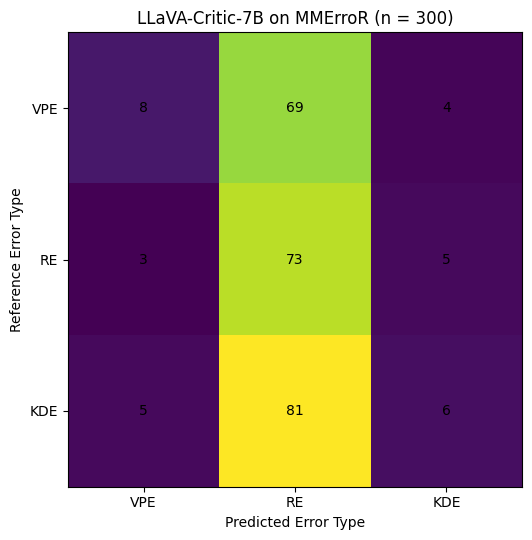

In [18]:
# 6.3 — Publication-quality confusion matrix

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.imshow(confusion)

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(["VPE", "RE", "KDE"])
ax.set_yticklabels(["VPE", "RE", "KDE"])

ax.set_xlabel("Predicted Error Type")
ax.set_ylabel("Reference Error Type")
ax.set_title("LLaVA-Critic-7B on MMErroR (n = 300)")

for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        ax.text(j, i, str(confusion[i, j]), ha="center", va="center")

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 7. Bootstrap Confidence Intervals

A non-parametric bootstrap with 5,000 resamples is used to estimate 95%
confidence intervals for Accuracy and Macro-F1.

In [19]:
# 7.1 — Bootstrap 95% confidence intervals

BOOTSTRAP_ITERATIONS = 5000
rng = np.random.default_rng(SEED)

gold = evaluation_results["gold_label"].to_numpy()
pred = evaluation_results["prediction_for_metric"].to_numpy()

bootstrap_accuracy = []
bootstrap_macro_f1 = []

for _ in range(BOOTSTRAP_ITERATIONS):
    indices = rng.integers(0, len(gold), size=len(gold))
    sampled_gold = gold[indices]
    sampled_pred = pred[indices]

    bootstrap_accuracy.append(
        accuracy_score(sampled_gold, sampled_pred)
    )
    bootstrap_macro_f1.append(
        f1_score(
            sampled_gold,
            sampled_pred,
            labels=TARGET_LABELS,
            average="macro",
            zero_division=0,
        )
    )

accuracy_ci = np.percentile(bootstrap_accuracy, [2.5, 97.5])
macro_f1_ci = np.percentile(bootstrap_macro_f1, [2.5, 97.5])

print(
    f"Accuracy 95% CI : [{accuracy_ci[0]:.4f}, {accuracy_ci[1]:.4f}]"
)
print(
    f"Macro-F1 95% CI : [{macro_f1_ci[0]:.4f}, {macro_f1_ci[1]:.4f}]"
)

Accuracy 95% CI : [0.2400, 0.3433]
Macro-F1 95% CI : [0.1862, 0.2777]


## 8. Error Analysis, Runtime, and Reproducibility Artifacts

In [20]:
# 8.1 — Save misclassified samples

misclassified_df = evaluation_results[
    evaluation_results["correct"] == False
].copy()

misclassified_df.to_csv(
    OUTPUT_DIR / "misclassified_samples.csv",
    index=False,
)

print("Misclassified/invalid samples:", len(misclassified_df))

display(
    misclassified_df[
        [
            "question_id",
            "gold_label",
            "predicted_label",
            "raw_output",
            "domain",
            "subdomain",
            "error",
        ]
    ].head(20)
)

Misclassified/invalid samples: 213


,question_id,gold_label,predicted_label,raw_output,domain,subdomain,error
0,MMErroR_00781,D,B,B,Biology & Healthcare,Human Anatomy & Disease,None
1,MMErroR_01493,D,B,B,Earth & Environment,Weather & Water Cycle,None
3,MMErroR_00525,A,B,B,Data & Analytics,Computing & Algorithms,None
4,MMErroR_01148,D,B,B,Mathematics & Logic,Geometric Figures,None
5,MMErroR_01876,D,B,B,Earth & Environment,Food Webs & Ecosystems,None
8,MMErroR_01868,A,B,B,Earth & Environment,Geology & Fossils,None
9,MMErroR_00871,B,A,A,Mathematics & Logic,Measurement & Units,None
10,MMErroR_00304,D,None,None,Biology & Healthcare,Human Anatomy & Disease,OutOfMemoryError('CUDA out of memory. Tried to...
11,MMErroR_01859,A,B,B,Physics & Engineering,Mechanics & Momentum,None
12,MMErroR_00371,D,B,B,Physics & Engineering,Electromagnetism & Waves,None


In [21]:
# 8.2 — Runtime summary

valid_times = evaluation_results["elapsed_seconds"].dropna()

runtime_summary = {
    "mean_seconds_per_sample": float(valid_times.mean()),
    "median_seconds_per_sample": float(valid_times.median()),
    "min_seconds_per_sample": float(valid_times.min()),
    "max_seconds_per_sample": float(valid_times.max()),
    "total_inference_minutes": float(valid_times.sum() / 60),
    "evaluation_wall_minutes": float(run_wall_seconds / 60),
}

for key, value in runtime_summary.items():
    print(f"{key:30s}: {value:.4f}")

mean_seconds_per_sample       : 2.4792
median_seconds_per_sample     : 2.1898
min_seconds_per_sample        : 1.4200
max_seconds_per_sample        : 4.5233
total_inference_minutes       : 10.7018
evaluation_wall_minutes       : 15.4410


In [22]:
# 8.3 — Save the aggregate result summary and run manifest

summary = {
    "experiment": (
        "LLaVA-Critic-7B zero-shot three-class MMErroR "
        "error-type classification"
    ),
    "model_id": MODEL_ID,
    "load_mode": LOAD_MODE,
    "dataset_path": str(DATA_PATH),
    "seed": SEED,
    "n_samples": N_SAMPLES,
    "class_quotas": CLASS_QUOTAS,
    "included_classes": {
        "A": "Visual Perception Error",
        "B": "Reasoning Error",
        "D": "Knowledge Deployment Error",
    },
    "excluded_class": "Question Comprehension Error",
    "accuracy": float(accuracy),
    "accuracy_95ci": [float(accuracy_ci[0]), float(accuracy_ci[1])],
    "macro_f1": float(macro_f1),
    "macro_f1_95ci": [float(macro_f1_ci[0]), float(macro_f1_ci[1])],
    "invalid_outputs": invalid_outputs,
    "strict_format_outputs": strict_outputs,
    "runtime": runtime_summary,
}

with open(
    OUTPUT_DIR / "evaluation_summary.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

manifest = {
    "model_id": MODEL_ID,
    "model_loader_name": MODEL_NAME,
    "conversation_template": CONVERSATION_TEMPLATE,
    "transformers_version": transformers.__version__,
    "transformers_pinned_commit": TRANSFORMERS_COMMIT,
    "tokenizers_version": tokenizers.__version__,
    "torch_version": torch.__version__,
    "cuda_version": torch.version.cuda,
    "load_mode": LOAD_MODE,
    "sampling_seed": SEED,
    "evaluation_size": N_SAMPLES,
    "class_quotas": CLASS_QUOTAS,
    "qce_included": False,
    "max_new_tokens": MAX_NEW_TOKENS,
    "decoding": {
        "do_sample": False,
        "temperature": 0,
    },
    "gpus": [
        torch.cuda.get_device_name(i)
        for i in range(torch.cuda.device_count())
    ],
}

with open(
    OUTPUT_DIR / "run_manifest.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "experiment": "LLaVA-Critic-7B zero-shot three-class MMErroR error-type classification",
  "model_id": "lmms-lab/llava-critic-7b",
  "load_mode": "standard",
  "dataset_path": "/kaggle/input/notebooks/vernvern/glimmer/mmerror_muse_glimmer_30b_eval/mmerror_complete.parquet",
  "seed": 42,
  "n_samples": 300,
  "class_quotas": {
    "A": 100,
    "B": 100,
    "D": 100
  },
  "included_classes": {
    "A": "Visual Perception Error",
    "B": "Reasoning Error",
    "D": "Knowledge Deployment Error"
  },
  "excluded_class": "Question Comprehension Error",
  "accuracy": 0.29,
  "accuracy_95ci": [
    0.24,
    0.3433333333333333
  ],
  "macro_f1": 0.23143041482354795,
  "macro_f1_95ci": [
    0.186190416265971,
    0.2776948809977268
  ],
  "invalid_outputs": 46,
  "strict_format_outputs": 254,
  "runtime": {
    "mean_seconds_per_sample": 2.4791774153822423,
    "median_seconds_per_sample": 2.1898335600001246,
    "min_seconds_per_sample": 1.4200207430001228,
    "max_seconds_per_sampl

## 9. Paper-Ready Results Table

This table summarizes the principal quantitative results in a compact form for
direct transfer to the experimental-results section.

In [23]:
# 9.1 — Create a compact paper-ready table

paper_results = pd.DataFrame({
    "Model": ["LLaVA-Critic-7B"],
    "Setting": ["Zero-shot"],
    "N": [N_SAMPLES],
    "Classes": ["VPE / RE / KDE"],
    "Accuracy": [accuracy],
    "Macro-F1": [macro_f1],
    "VPE F1": [class_f1[0]],
    "RE F1": [class_f1[1]],
    "KDE F1": [class_f1[2]],
    "Invalid Outputs": [invalid_outputs],
})

display(paper_results)

paper_results.to_csv(
    OUTPUT_DIR / "paper_ready_results.csv",
    index=False,
)

with open(
    OUTPUT_DIR / "paper_ready_results.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        paper_results.to_latex(
            index=False,
            float_format="%.4f",
        )
    )

print("Paper-ready CSV and LaTeX tables saved.")

,Model,Setting,N,Classes,Accuracy,Macro-F1,VPE F1,RE F1,KDE F1,Invalid Outputs
0,LLaVA-Critic-7B,Zero-shot,300,VPE / RE / KDE,0.29,0.23143,0.137931,0.452012,0.104348,46


Paper-ready CSV and LaTeX tables saved.


## Output Artifacts

All outputs are stored in:

`/kaggle/working/llava_critic_mmerror_300_balanced/`

Key files:

- `evaluation_300_ids.json`
- `evaluation_300_metadata.csv`
- `predictions_300.csv`
- `class_metrics.csv`
- `confusion_matrix.csv`
- `confusion_matrix.png`
- `misclassified_samples.csv`
- `evaluation_summary.json`
- `run_manifest.json`
- `paper_ready_results.csv`
- `paper_ready_results.tex`

### Leakage control for later fine-tuning

The 300 identifiers in `evaluation_300_ids.json` must be excluded from the
MMErroR fine-tuning set. The fine-tuned judge should then be evaluated on this
exact cohort to obtain a valid before/after comparison.